# Single PHOEBE + SPICE eclipse system

Builds **one** binary the same way `check_phoebe_eclipses.py` does, runs both PHOEBE and SPICE on the eclipse window, and plots the bolometric light curves side by side.

Useful for interactive exploration / plot tweaks without launching the full grid.

In [1]:
import os
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')
os.environ.setdefault('XLA_PYTHON_CLIENT_ALLOCATOR', 'platform')

import jax
jax.config.update('jax_enable_x64', False)
jax.config.update('jax_platform_name', 'cpu')

import sys
sys.path.append('/Users/mjablons/code/spice/src')

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from astropy import units as u

import phoebe
from phoebe.parameters.dataset import _mesh_columns

from spice.models.binary import (
    Binary,
    add_orbit,
    evaluate_orbit_at_times,
    evaluate_orbit_at_times_stacked,
)
from spice.models.mesh_model import IcosphereModel
from spice.models.mesh_view import get_mesh_view
from spice.models.orbit_utils import eclipse_timestamps_kepler
from spice.spectrum.blackbody import Blackbody
from spice.spectrum.filter import Bolometric
from spice.spectrum.spectrum import AB_passband_luminosity, simulate_observed_flux

%matplotlib inline

DAYS_TO_YR = 0.0027378507871321013
DEG_TO_RAD = 0.017453292519943295

Connection to online passbands at https://tables.phoebe-project.org could not be established.  Check your internet connection or try again later (can manually call phoebe.list_online_passbands(refresh=True) to retry).  If the problem persists and you're using a Mac, you may need to update openssl (see https://phoebe-project.org/help/faq). Original error from urlopen: URLError <urlopen error [Errno 101] Network is unreachable>


## Parameters

Edit these to explore other geometries. Defaults match a clean, fully eclipsing case.

In [2]:
inclination     = 90.0   # degrees
period          = 5.0    # days
q               = 0.5    # mass ratio
ecc             = 0.0    # eccentricity
primary_mass    = 1.0    # Msun
n_times         = 20     # samples (split evenly between primary/secondary eclipse)
n_mesh_elements = 5000   # both SPICE icosphere and PHOEBE ntriangles

## Build PHOEBE bundle and pick the eclipse window

We use SPICE's `eclipse_timestamps_kepler` to find the primary and secondary eclipse contact times so PHOEBE only computes inside the windows of interest.

In [3]:
phoebe.multiprocessing_set_nprocs(1)

b = phoebe.default_binary()
b.flip_constraint('mass@primary', solve_for='sma')
b.set_value_all('ntriangles@primary', 5000)
b.set_value('period@binary@component', period)
b.set_value('q@binary@component', q)
b.set_value('ecc@binary@component', ecc)
b.set_value('mass@primary@component', primary_mass)
b.set_value_all('incl@binary', inclination)
b.set_value('requiv@secondary@component', 0.57)

In [4]:
b.get_parameter('requiv@primary@component').value, b.get_parameter('requiv@secondary@component').value, b.get_parameter('q@binary@component')

(np.float64(1.0),
 np.float64(0.57),
 <Parameter: q=0.5 | keys: description, value, quantity, default_unit, limits, visible_if, copy_for, readonly, advanced, latexfmt>)

In [5]:
_, t1_p, _, _, t4_p, _, t1_s, _, _, t4_s = eclipse_timestamps_kepler(
    b.get_parameter('mass@primary@component').value,
    b.get_parameter('mass@secondary@component').value,
    b.get_parameter('period@binary@component').value * DAYS_TO_YR,
    b.get_parameter('ecc@binary@component').value,
    b.get_parameter('t0_perpass@binary@component').value * DAYS_TO_YR,
    jnp.deg2rad(b.get_parameter('incl@binary@component').value),
    b.get_parameter('per0@binary@component').value * DEG_TO_RAD,
    b.get_parameter('long_an@binary@component').value * DEG_TO_RAD,
    b.get_parameter('requiv@primary@component').value,
    b.get_parameter('requiv@secondary@component').value,
    pad=1.1,
    los_vector=jnp.array([0., 0., -1.]),
)

eclipse_edges = (float(t1_p), float(t4_p), float(t1_s), float(t4_s))
if not all(np.isfinite(eclipse_edges)):
    raise RuntimeError(f'No eclipse for this geometry: edges={eclipse_edges}')

half = int(n_times / 2)
times = np.concatenate([
    np.linspace(eclipse_edges[0] / DAYS_TO_YR, eclipse_edges[1] / DAYS_TO_YR, half),
    np.linspace(eclipse_edges[2] / DAYS_TO_YR, eclipse_edges[3] / DAYS_TO_YR, half),
])
times_yr = times * DAYS_TO_YR
print(f'Primary eclipse window  [d]: {eclipse_edges[0] / DAYS_TO_YR:.4f} - {eclipse_edges[1] / DAYS_TO_YR:.4f}')
print(f'Secondary eclipse window [d]: {eclipse_edges[2] / DAYS_TO_YR:.4f} - {eclipse_edges[3] / DAYS_TO_YR:.4f}')

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:135: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE
/scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/jax/_src/lax/lax.py:5095: RuntimeWarning: overflow encountered in cast
  out = out.ast

Primary eclipse window  [d]: -0.0887 - 0.0887
Secondary eclipse window [d]: 2.4112 - 2.5886


In [11]:
b.add_dataset('mesh', compute_times=times, columns=_mesh_columns, dataset='mesh01')
b.add_dataset('orb', compute_times=times, dataset='orb01')
b.add_dataset('lc', compute_times=times,
              passband='Bolometric:900-40000', dataset='lc_bolometric')
b.set_value_all('pblum_mode', dataset='lc_bolometric', value='absolute')
b.set_value('distance', 10 * u.pc)
b.set_value_all('ld_mode', 'manual')
b.set_value_all('ld_func', 'linear')
b.set_value_all('ld_coeffs', [0.])
b.set_value_all('ld_mode_bol', 'manual')
b.set_value_all('ld_func_bol', 'linear')
b.set_value_all('ld_coeffs_bol', [0.])
b.set_value_all('atm', 'blackbody')
b.set_value_all('irrad_method', 'none')
b.set_value_all('gravb_bol', 0.0)

b.compute_pblums(pbflux=True, set_value=True)
b.compute_ld_coeffs(ld_mode='manual', ld_func='linear', ld_coeffs=[0.])
b.run_compute(irrad_method='none', coordinates='uvw', ltte=False, ntriangles=n_mesh_elements)

fluxes_phoebe = np.asarray(b.get_parameter('fluxes@lc_bolometric@model').value)

ValueError: label 'mesh01' is already in use.  Remove first or pass overwrite=True, if available.

In [7]:
len(b.get_value('us@primary', time=times[0]))

5784

## SPICE bolometric light curve

Same orbital parameters, blackbody atmosphere, no limb darkening — matched as closely as possible to the PHOEBE setup above.

In [8]:
bb = Blackbody()
bol = Bolometric()

def default_icosphere(mass, radius):
    return get_mesh_view(
        IcosphereModel.construct(n_mesh_elements, radius, mass,
                                 bb.solar_parameters, bb.parameter_names),
        jnp.array([0., 0., -1.]),
    )

body1 = default_icosphere(
    b.get_parameter('mass@primary@component').value,
    b.get_parameter('requiv@primary@component').value,
)
body2 = default_icosphere(
    b.get_parameter('mass@secondary@component').value,
    b.get_parameter('requiv@secondary@component').value,
)
binary = Binary.from_bodies(body1, body2)
binary = add_orbit(
    binary,
    P=b.get_parameter('period@binary@component').value * DAYS_TO_YR,
    ecc=b.get_parameter('ecc@binary@component').value,
    # `T` (periastron-passage time) is required by add_orbit but currently a no-op
    # inside get_orbit_jax — orbit phase is set entirely by `mean_anomaly` (treated as
    # M at t=0). PHOEBE's mean_anom is M(t=t0_ref); for default_binary t0_ref=0 these
    # coincide.
    T=0.0,
    i=jnp.deg2rad(b.get_parameter('incl@binary@component').value),
    omega=b.get_parameter('per0@binary@component').value * DEG_TO_RAD,
    Omega=b.get_parameter('long_an@binary@component').value * DEG_TO_RAD,
    # PHOEBE vgamma is km/s; get_orbit_jax converts internally.
    vgamma=b.get_parameter('vgamma').value,
    reference_time=b.get_parameter('t0_ref@binary@component').value * DAYS_TO_YR,
    mean_anomaly=b.get_parameter('mean_anom@binary@component').value * DEG_TO_RAD,
    # See check_phoebe_eclipses.py: orbit positions are linearly interpolated from
    # a uniform [0,P] grid, so density << eclipse-width / P leaves the eclipse
    # window essentially unsampled. 10000 keeps interpolation error sub-percent.
    orbit_resolution_points=10000,
)

# Stacked pytrees (leading time axis) feed the lax.map-batched spectra
# computation below. The per-time list `pb1`/`pb2` is what the diagnostic
# cells expect; `evaluate_orbit_at_times` shares the same jit-cached kernel
# as the stacked call, so it's near-free after the first.
stacked_pb1, stacked_pb2 = evaluate_orbit_at_times_stacked(binary, times_yr)
pb1, pb2 = evaluate_orbit_at_times(binary, times_yr)

/scratch/y89/mj8805/spice/src/spice/models/mesh_model.py:295: UserWarning: If override_log_g is True, either parameter_names must include one of [logg,loggs,log_g,log_gs,log g,log gs,surface gravity,surface gravities,surface_gravity,surface_gravities], or log_g_index must be passed for log g to be used in the spectrum emulator.
  warnings.warn(f"If override_log_g is True, either parameter_names must include one of [" + ",".join(


[spice] IcosphereModel constructed in 3.8 s
[spice] IcosphereModel constructed in 0.0 s
[spice] Binary orbit evaluated in 3.2 s
[spice] Binary orbit evaluated in 112.4 s


In [12]:
vws = jnp.linspace(900, 40000, 1000)
log_vws = jnp.log10(vws)

# Batched bolometric LC: lax.map compiles the per-time computation once and
# reuses it across the 100 timesteps, dropping the per-iter Python dispatch
# overhead of the previous `for _pb1, _pb2 in zip(pb1, pb2)` loop. Use
# `jax.vmap` here instead if you want batch parallelism — note that vmap'd
# over 100 timesteps blows up the chunk-scan intermediates by ~100x, which
# can OOM at the default chunk_size=1024.
def _per_time_bol_lum(mesh_pair):
    m1, m2 = mesh_pair
    spec1 = simulate_observed_flux(bb.intensity, m1, log_vws, disable_doppler_shift=True)
    spec2 = simulate_observed_flux(bb.intensity, m2, log_vws, disable_doppler_shift=True)
    return AB_passband_luminosity(bol, vws, spec1[:, 0] + spec2[:, 0])

bol_lum = np.array(jax.lax.map(_per_time_bol_lum, (stacked_pb1, stacked_pb2)))
spice_mag = bol_lum - bol_lum[0]

phoebe_mag_raw = -2.5 * np.log10(np.asarray(fluxes_phoebe, dtype=float))
phoebe_mag = phoebe_mag_raw - phoebe_mag_raw[0]
residual = spice_mag - phoebe_mag

## Plot the comparison

Top row: PHOEBE vs SPICE bolometric magnitudes (zeroed at $t_0$).

Middle row: SPICE − PHOEBE magnitude residual.

Bottom row: visibility residual for the eclipsed star in each window (SPICE − PHOEBE in visible 3D-area fraction), same convention as the dedicated visibility figure below.

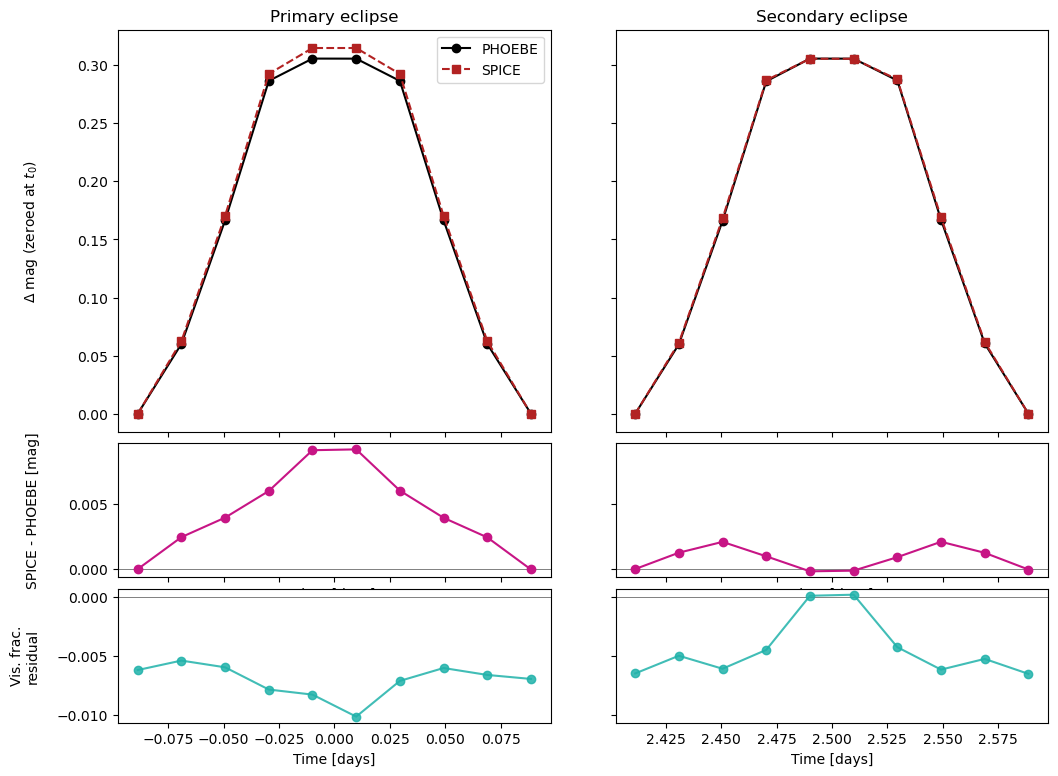

max |residual| = 9.1512e-03 mag
rms residual   = 3.8369e-03 mag
max |visibility residual| = 1.0130e-02
rms  visibility residual  = 6.1818e-03


In [13]:
def get_visible_frac(b, time, body='primary'):
    # Visible 3D-area fraction of `body` at `time` from PHOEBE.
    vis = b.get_value(f'visibilities@{body}', time=time)
    area = b.get_value(f'areas@{body}', time=time)
    return np.sum(area * vis) / np.sum(area)


def get_visible_frac_spice(mesh):
    base = np.asarray(mesh.base_areas)
    cast = np.asarray(mesh.cast_areas)
    vis_cast = np.asarray(mesh.visible_cast_areas)
    visibility = np.divide(vis_cast, cast, out=np.zeros_like(cast), where=cast > 0)
    return np.sum(base * visibility) / np.sum(base)


t_primary = times[:half]
t_secondary = times[half:]

vis_phoebe_primary = np.array([get_visible_frac(b, t, 'primary') for t in times])
vis_phoebe_secondary = np.array([get_visible_frac(b, t, 'secondary') for t in times])
vis_spice_primary = np.array([get_visible_frac_spice(m) for m in pb1])
vis_spice_secondary = np.array([get_visible_frac_spice(m) for m in pb2])

# Eclipsed body in each window (same convention as the visibility figure below).
residual_visibility = np.empty_like(vis_phoebe_primary)
residual_visibility[:half] = vis_spice_primary[:half] - vis_phoebe_primary[:half]
residual_visibility[half:] = vis_spice_secondary[half:] - vis_phoebe_secondary[half:]

fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex='col', sharey='row',
                         gridspec_kw={'height_ratios': [3, 1, 1], 'hspace': 0.05, 'wspace': 0.15})

for ax_lc, ax_res, ax_vis, t, sl, title in (
    (axes[0, 0], axes[1, 0], axes[2, 0], t_primary, slice(0, half), 'Primary eclipse'),
    (axes[0, 1], axes[1, 1], axes[2, 1], t_secondary, slice(half, None), 'Secondary eclipse'),
):
    ax_lc.plot(t, phoebe_mag[sl], 'o-', label='PHOEBE', color='black')
    ax_lc.plot(t, spice_mag[sl], 's--', label='SPICE', color='firebrick')
    ax_lc.invert_yaxis()
    ax_lc.set_title(title)

    ax_res.axhline(0, color='gray', lw=0.7)
    ax_res.plot(t, residual[sl], 'o-', color='mediumvioletred')
    ax_res.set_xlabel('Time [days]')

    ax_vis.axhline(0, color='gray', lw=0.7)
    ax_vis.plot(t, residual_visibility[sl], 'o-', color='lightseagreen', alpha=0.85)
    ax_vis.set_xlabel('Time [days]')

# Align y-labels across all rows to be at the same vertical position
for row in range(3):
    axes[row, 0].set_ylabel({
        0: r'$\Delta$ mag (zeroed at $t_0$)',
        1: 'SPICE - PHOEBE [mag]',
        2: 'Vis. frac.\nresidual',
    }[row], labelpad=40)
    axes[row, 0].yaxis.set_label_coords(-0.18, 0.5)  # -.18 may need tuning if padding is odd; ideal for 12in × 9in

axes[0, 0].legend(loc='best')
plt.show()

print(f'max |residual| = {np.nanmax(np.abs(residual)):.4e} mag')
print(f'rms residual   = {np.sqrt(np.nanmean(residual**2)):.4e} mag')
print(f'max |visibility residual| = {np.nanmax(np.abs(residual_visibility)):.4e}')
print(f'rms  visibility residual  = {np.sqrt(np.nanmean(residual_visibility**2)):.4e}')

In [14]:
fig.savefig('single_eclipse_system_residuals.pdf', bbox_inches='tight', dpi=300)

In [ ]:
b.get_parameter('visibilities@primary', time=times[0]).description

'Visiblity of triangles (1=visible, 0.5=partial, 0=hidden)'

In [ ]:
def get_visible_frac(b, time, body='primary'):
    # Visible 3D-area fraction of `body` at `time` from PHOEBE.
    vis  = b.get_value(f'visibilities@{body}', time=time)
    area = b.get_value(f'areas@{body}', time=time)
    return np.sum(area * vis) / np.sum(area)

def get_visible_frac_spice(mesh):
    base     = np.asarray(mesh.base_areas)
    cast     = np.asarray(mesh.cast_areas)
    vis_cast = np.asarray(mesh.visible_cast_areas)
    visibility = np.divide(vis_cast, cast, out=np.zeros_like(cast), where=cast > 0)
    return np.sum(base * visibility) / np.sum(base)

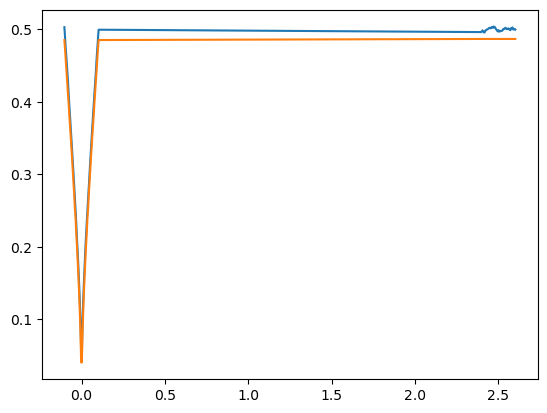

In [ ]:
fracs = [get_visible_frac(b, t) for t in times]
fracs_spice = [get_visible_frac_spice(_p) for _p in pb1]
plt.plot(times, fracs)
plt.plot(times, fracs_spice)

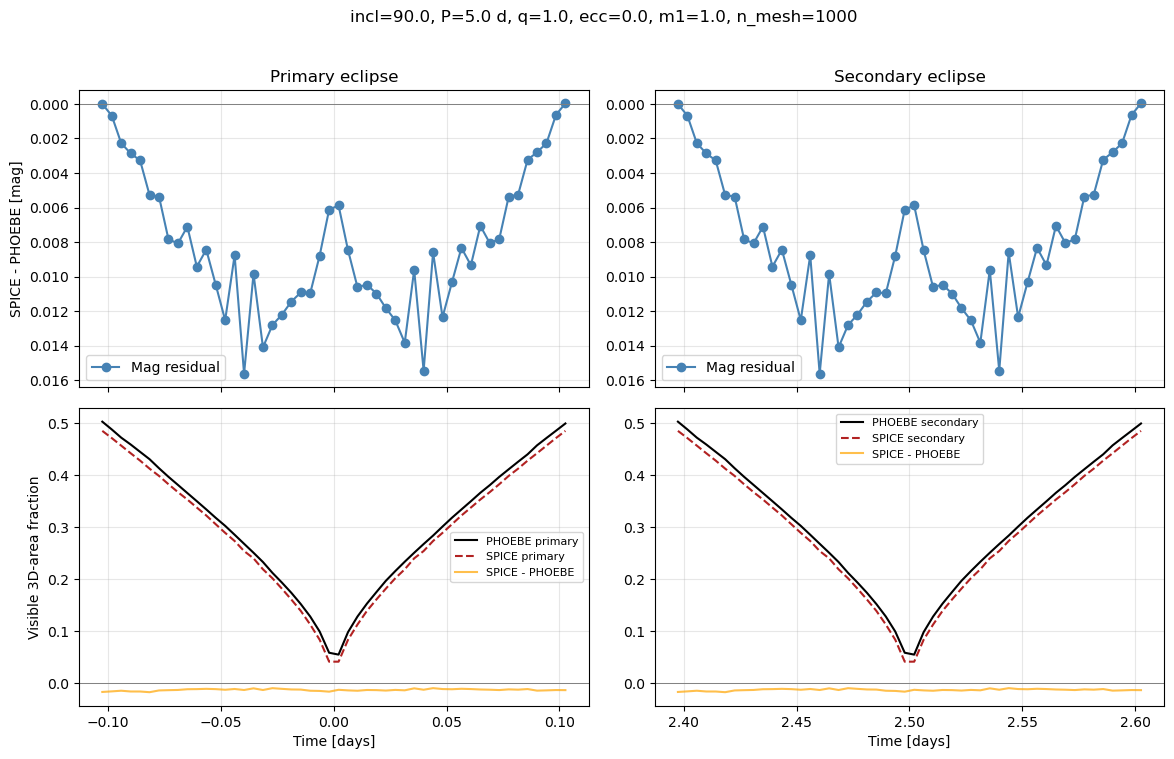

max |mag residual|        = 1.5627e-02 mag
rms  mag residual         = 9.0694e-03 mag
max |visibility residual| = 1.8219e-02
rms  visibility residual  = 1.3930e-02


In [ ]:
t_primary   = times[:half]
t_secondary = times[half:]

# Visible-fraction time series for both bodies in both codes.
vis_phoebe_primary   = np.array([get_visible_frac(b, t, 'primary')   for t in times])
vis_phoebe_secondary = np.array([get_visible_frac(b, t, 'secondary') for t in times])
vis_spice_primary    = np.array([get_visible_frac_spice(m) for m in pb1])
vis_spice_secondary  = np.array([get_visible_frac_spice(m) for m in pb2])

# The interesting comparison is the *eclipsed* body in each window:
#   primary eclipse   -> primary is being occluded
#   secondary eclipse -> secondary is being occluded
# (the occluder is ~fully visible the whole time, so its residual is uninformative.)
residual_visibility = np.empty_like(vis_phoebe_primary)
residual_visibility[:half] = vis_spice_primary[:half]   - vis_phoebe_primary[:half]
residual_visibility[half:] = vis_spice_secondary[half:] - vis_phoebe_secondary[half:]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex='col',
                         gridspec_kw={'hspace': 0.07, 'wspace': 0.13})

# Top row: bolometric mag residuals (from the LC plot above).
axes[0, 0].plot(t_primary,   residual[:half], 'o-', color='steelblue', label='Mag residual')
axes[0, 0].set_title('Primary eclipse')
axes[0, 0].set_ylabel('SPICE - PHOEBE [mag]')
axes[0, 0].axhline(0, color='gray', lw=0.7)
axes[0, 0].invert_yaxis()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend(loc='best')

axes[0, 1].plot(t_secondary, residual[half:], 'o-', color='steelblue', label='Mag residual')
axes[0, 1].set_title('Secondary eclipse')
axes[0, 1].axhline(0, color='gray', lw=0.7)
axes[0, 1].invert_yaxis()
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend(loc='best')

# Bottom row: visible 3D-area fraction of the eclipsed body — both codes plus the residual.
axes[1, 0].plot(t_primary, vis_phoebe_primary[:half], 'k-',  label='PHOEBE primary')
axes[1, 0].plot(t_primary, vis_spice_primary[:half],  color='firebrick', linestyle='--', label='SPICE primary')
axes[1, 0].plot(t_primary, residual_visibility[:half], color='orange', alpha=0.7, label='SPICE - PHOEBE')
axes[1, 0].set_xlabel('Time [days]')
axes[1, 0].set_ylabel('Visible 3D-area fraction')
axes[1, 0].axhline(0, color='gray', lw=0.7)
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(fontsize=8, loc='best')

axes[1, 1].plot(t_secondary, vis_phoebe_secondary[half:], 'k-',  label='PHOEBE secondary')
axes[1, 1].plot(t_secondary, vis_spice_secondary[half:],  color='firebrick', linestyle='--', label='SPICE secondary')
axes[1, 1].plot(t_secondary, residual_visibility[half:], color='orange', alpha=0.7, label='SPICE - PHOEBE')
axes[1, 1].set_xlabel('Time [days]')
axes[1, 1].axhline(0, color='gray', lw=0.7)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend(fontsize=8, loc='best')

fig.suptitle(
    f'incl={inclination}, P={period} d, q={q}, ecc={ecc}, '
    f'm1={primary_mass}, n_mesh={n_mesh_elements}'
)
plt.show()

print(f'max |mag residual|        = {np.nanmax(np.abs(residual)):.4e} mag')
print(f'rms  mag residual         = {np.sqrt(np.nanmean(residual**2)):.4e} mag')
print(f'max |visibility residual| = {np.nanmax(np.abs(residual_visibility)):.4e}')
print(f'rms  visibility residual  = {np.sqrt(np.nanmean(residual_visibility**2)):.4e}')

## Where do PHOEBE and SPICE actually disagree?

The 3D-area visibility curve above tells you *how much* the codes disagree at each phase. The cells below show two complementary views:

1. **Spatial mesh maps** at mid-primary and mid-secondary eclipse — each panel scatters mesh elements in the (u, v) image plane, colored by per-element visibility. The shape of the disagreement (a ring? the limb? the eclipsed region?) is the diagnostic.
2. **Per-element visibility histograms** at mid-primary — PHOEBE's `visibilities` is bucketed at {0, 0.5, 1}; SPICE's polygon clip against the companion silhouette is continuous. The histogram shape difference is exactly the per-element source of the LC residual.

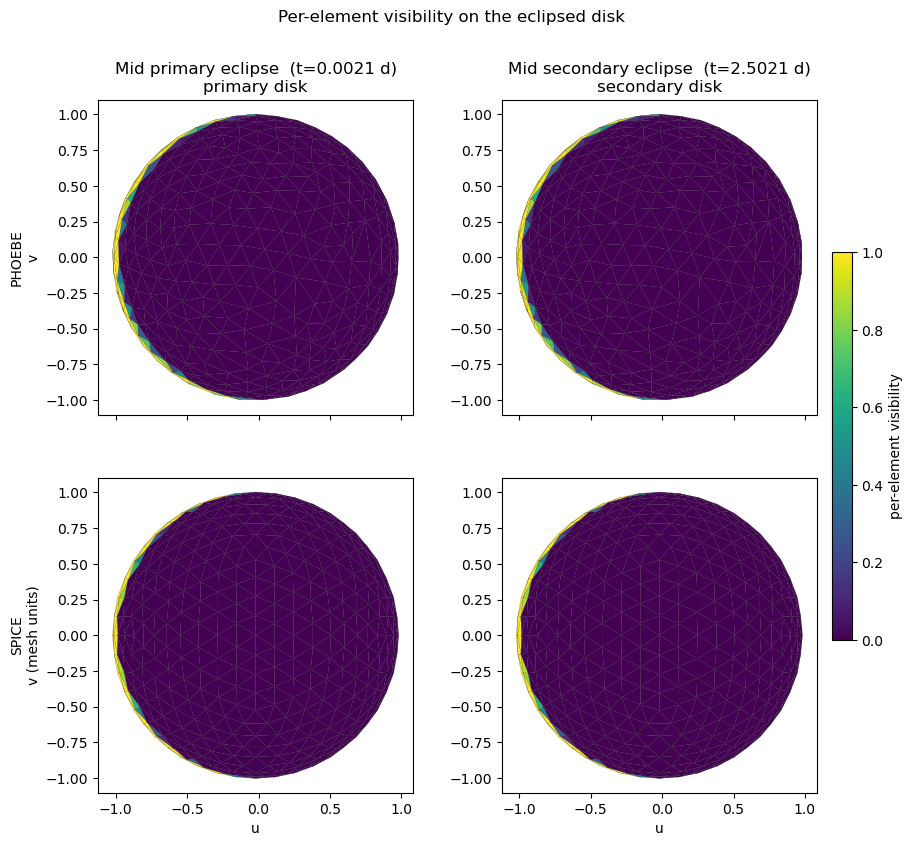

In [ ]:
from matplotlib.collections import PolyCollection

def phoebe_polys_vis(b, body, t):
    # uvw_elements: (N_triangles, 3 vertices, 3 axes (u, v, w))
    uvw = np.asarray(b.get_value(f'uvw_elements@{body}', time=t))
    polys = uvw[:, :, :2]
    vis = np.asarray(b.get_value(f'visibilities@{body}', time=t))
    mu  = np.asarray(b.get_value(f'mus@{body}', time=t))
    return polys, vis, mu

def spice_polys_vis(mesh):
    # Remap SPICE's (u, v) basis to PHOEBE's so the two plots overlay.
    # cast_to_normal_plane(LOS=[0,0,-1]) returns (u_SPICE, v_SPICE) = (-y_3D, -x_3D);
    # PHOEBE's `uvw` uses (u, v) = (+x_3D, +y_3D), so we swap and negate.
    verts2d = np.asarray(mesh.cast_vertices)
    faces   = np.asarray(mesh.faces).astype(int)
    polys   = verts2d[faces]
    polys   = np.stack([-polys[..., 1], -polys[..., 0]], axis=-1)
    cast    = np.asarray(mesh.cast_areas)
    vis_cast = np.asarray(mesh.visible_cast_areas)
    vis = np.divide(vis_cast, cast, out=np.zeros_like(cast), where=cast > 0)
    mu  = np.asarray(mesh.mus)
    return polys, vis, mu

def draw_mesh(ax, polys, vis, mu, *, only_front=True):
    """Render mesh triangles colored by per-element visibility.
    Back-facing triangles are dropped by default so the disk reads cleanly."""
    if only_front:
        keep = mu > 0
        polys = polys[keep]
        vis = vis[keep]
    pc = PolyCollection(polys, array=vis, cmap='viridis',
                        edgecolors='black', linewidths=0.1)
    pc.set_clim(0, 1)
    ax.add_collection(pc)
    ax.autoscale_view()
    return pc

snapshots = [
    ('Mid primary eclipse',   half // 2,        'primary',   pb1),
    ('Mid secondary eclipse', half + half // 2, 'secondary', pb2),
]

fig, axes = plt.subplots(2, len(snapshots), figsize=(5 * len(snapshots), 9),
                         sharex='col', sharey='col')
for col, (label, idx, body, spice_meshes) in enumerate(snapshots):
    t = times[idx]
    pp, vp, mp = phoebe_polys_vis(b, body, t)
    sp, vs, ms = spice_polys_vis(spice_meshes[idx])

    draw_mesh(axes[0, col], pp, vp, mp)
    pc = draw_mesh(axes[1, col], sp, vs, ms)
    axes[0, col].set_title(f'{label}  (t={t:.4f} d)\n{body} disk')
    axes[0, col].set_aspect('equal')
    axes[1, col].set_aspect('equal')
    axes[1, col].set_xlabel('u')

axes[0, 0].set_ylabel('PHOEBE\nv')
axes[1, 0].set_ylabel('SPICE\nv (mesh units)')
fig.colorbar(pc, ax=axes.ravel().tolist(),
             label='per-element visibility', fraction=0.025, pad=0.02)
fig.suptitle('Per-element visibility on the eclipsed disk')
plt.show()

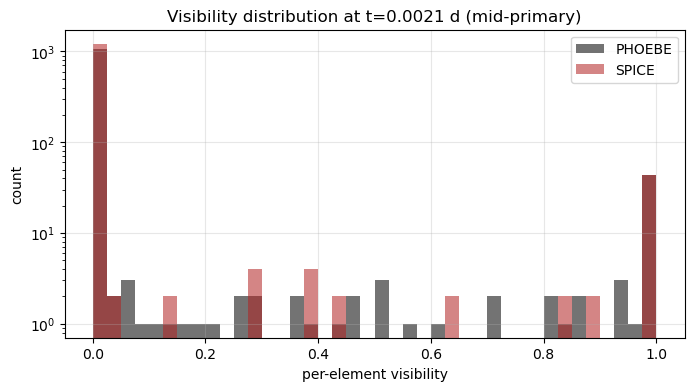

PHOEBE partially-visible elements: 59
SPICE  partially-visible elements: 20


In [ ]:
# Histogram of per-element visibilities at mid-primary eclipse.
# PHOEBE's visibilities are quantized at {0, 0.5, 1}; SPICE's are continuous
# because each element is clipped against the companion silhouette.
idx = half // 2
_, visp, _ = phoebe_polys_vis(b, 'primary', times[idx])
_, viss, _ = spice_polys_vis(pb1[idx])

edges = np.linspace(0, 1, 41)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(visp, bins=edges, alpha=0.55, label='PHOEBE', color='black')
ax.hist(viss, bins=edges, alpha=0.55, label='SPICE',  color='firebrick')
ax.set_xlabel('per-element visibility')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.set_title(f'Visibility distribution at t={times[idx]:.4f} d (mid-primary)')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

phoebe_partial = np.sum((visp > 0) & (visp < 1))
spice_partial  = np.sum((viss > 0) & (viss < 1))
print(f'PHOEBE partially-visible elements: {phoebe_partial}')
print(f'SPICE  partially-visible elements: {spice_partial}')

## Basis sanity check: body-center trajectories

After the `(u, v)_SPICE → (-v, -u)` remap inside `spice_polys_vis`, PHOEBE's `orb01` body centers and SPICE's `mesh.center` should overlay in the (u, v) plane. Any residual after this check indicates either a remaining basis bug or a real orbit-phase mismatch.

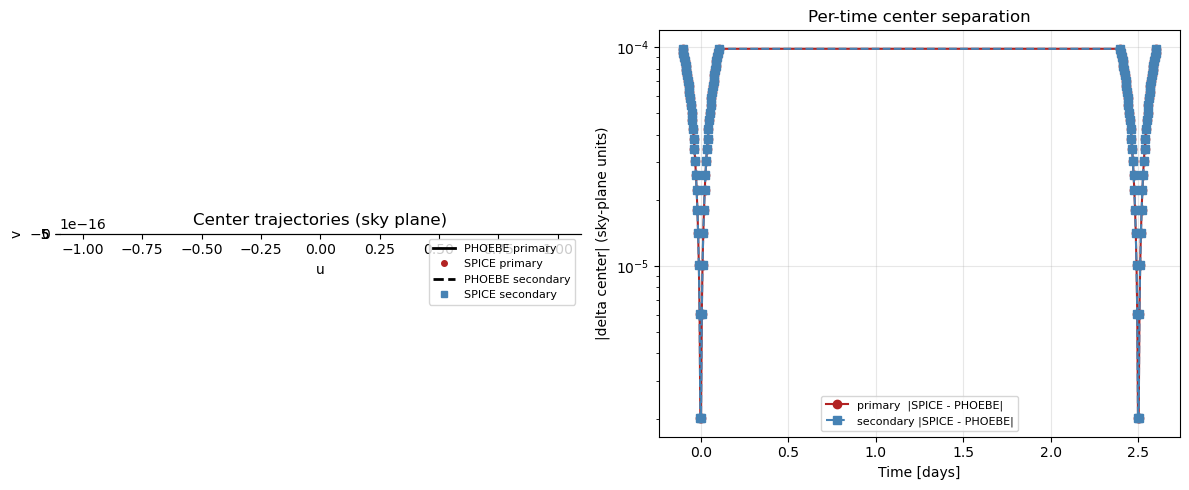

max |delta center| primary   = 9.8612e-05  (6.36e-04% of sma=15.503)
max |delta center| secondary = 9.8612e-05  (6.36e-04% of sma=15.503)


In [ ]:
# PHOEBE body centers in the sky plane, sampled on the orb01 dataset.
us_p_ph = np.asarray(b.get_value('us@primary@orb01'))
vs_p_ph = np.asarray(b.get_value('vs@primary@orb01'))
us_s_ph = np.asarray(b.get_value('us@secondary@orb01'))
vs_s_ph = np.asarray(b.get_value('vs@secondary@orb01'))

# SPICE body centers projected to the same basis. With LOS = [0, 0, -1] the
# remap (u, v)_SPICE -> (-v, -u) collapses to (x_3D, y_3D), so we just read
# the body center's first two components directly.
us_p_sp = np.array([float(m.center[0]) for m in pb1])
vs_p_sp = np.array([float(m.center[1]) for m in pb1])
us_s_sp = np.array([float(m.center[0]) for m in pb2])
vs_s_sp = np.array([float(m.center[1]) for m in pb2])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(us_p_ph, vs_p_ph, 'k-',  lw=2, label='PHOEBE primary')
ax.plot(us_p_sp, vs_p_sp, 'o',   color='firebrick', ms=4, label='SPICE primary')
ax.plot(us_s_ph, vs_s_ph, color='black', linestyle='--', lw=2, label='PHOEBE secondary')
ax.plot(us_s_sp, vs_s_sp, 's',   color='steelblue', ms=4, label='SPICE secondary')
ax.set_xlabel('u'); ax.set_ylabel('v')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='best')
ax.set_title('Center trajectories (sky plane)')

ax = axes[1]
ax.plot(times, np.hypot(us_p_sp - us_p_ph, vs_p_sp - vs_p_ph),
        'o-', color='firebrick', label='primary  |SPICE - PHOEBE|')
ax.plot(times, np.hypot(us_s_sp - us_s_ph, vs_s_sp - vs_s_ph),
        's--', color='steelblue', label='secondary |SPICE - PHOEBE|')
ax.set_xlabel('Time [days]')
ax.set_ylabel('|delta center| (sky-plane units)')
ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='best')
ax.set_title('Per-time center separation')

plt.tight_layout()
plt.show()

max_p = np.max(np.hypot(us_p_sp - us_p_ph, vs_p_sp - vs_p_ph))
max_s = np.max(np.hypot(us_s_sp - us_s_ph, vs_s_sp - vs_s_ph))
scale = float(b.get_parameter('sma@binary@component').value)
print(f'max |delta center| primary   = {max_p:.4e}  ({max_p/scale*100:.2e}% of sma={scale:.3f})')
print(f'max |delta center| secondary = {max_s:.4e}  ({max_s/scale*100:.2e}% of sma={scale:.3f})')

## (Optional) Save in the same pickle layout as the grid script

Useful if you want to drop the result into the existing `blackbody_comparison.ipynb` loader.

In [ ]:
import pickle
from pathlib import Path

SAVE = False  # flip to True to write the pickle
OUTPUT_PATH = Path('lc_eclipse')

if SAVE:
    OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
    out_pkl = OUTPUT_PATH / (
        f'eclipses_incl_{inclination}_period_{period}_q_{q}_ecc_{ecc}'
        f'_primary_mass_{primary_mass}_nmesh_{n_mesh_elements}.pkl'
    )
    with open(out_pkl, 'wb') as f:
        pickle.dump({
            'phoebe_binary': b,
            'spice_body1': pb1,
            'spice_body2': pb2,
            'fluxes_phoebe': fluxes_phoebe,
            'bol_lum': spice_mag,
            'times': times,
            'n_times': n_times,
            'sma': b.get_parameter('sma@binary@component').value,
            'primary_mass': primary_mass,
            'secondary_mass': b.get_parameter('mass@secondary@component').value,
            'inclination': inclination,
            'period': period,
            'q': q,
            'ecc': ecc,
            'n_mesh_elements': n_mesh_elements,
        }, f)
    print(f'wrote {out_pkl}')